<a href="https://colab.research.google.com/github/aishujadhav1321/Tesla-Stock-Price-Prediction/blob/main/Tesla_Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
df = pd.read_csv("TSLA.csv")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [7]:
print(df.shape)

(2416, 7)


In [8]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [10]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [11]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [12]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_2439/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [13]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [14]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

In [15]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


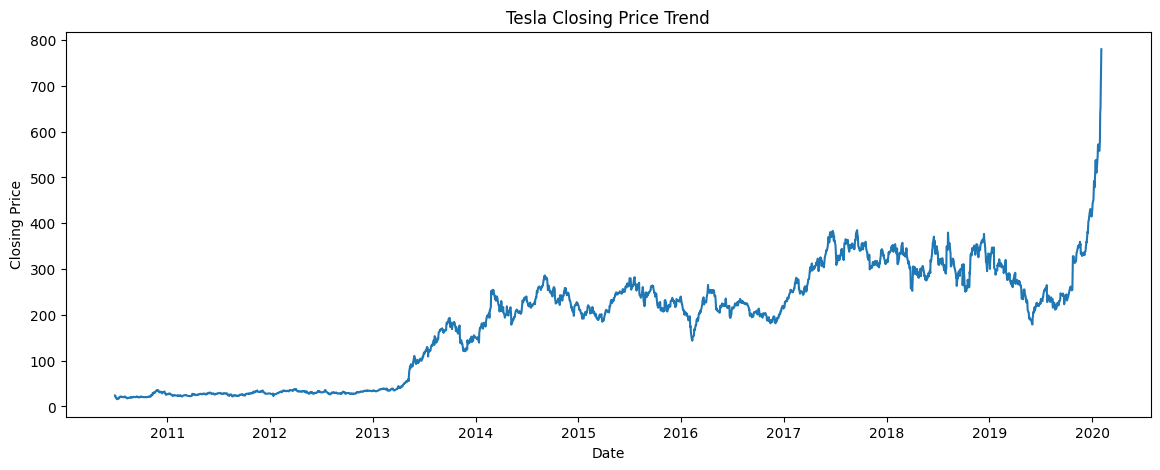

In [16]:
plt.figure(figsize=(14,5))

plt.plot(df['Close'])

plt.title("Tesla Closing Price Trend")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.show()

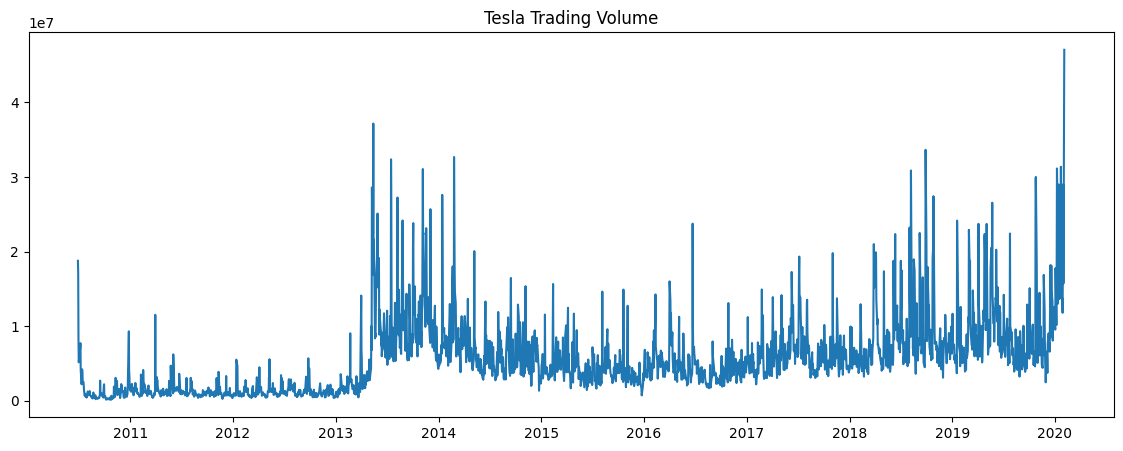

In [17]:
plt.figure(figsize=(14,5))

plt.plot(df['Volume'])

plt.title("Tesla Trading Volume")

plt.show()

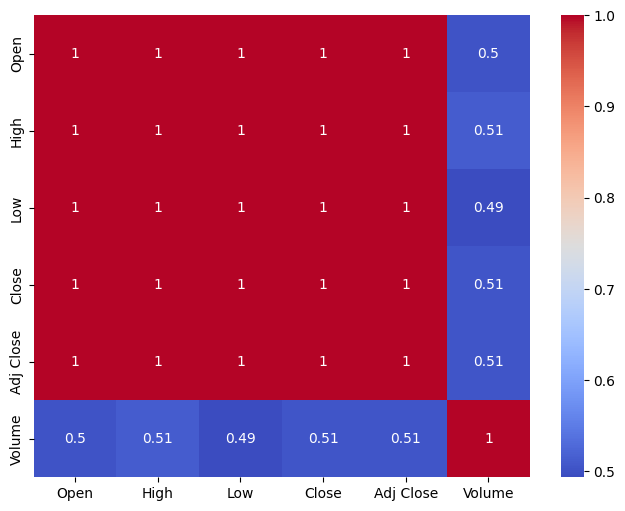

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [19]:
data = df[['Close']]

In [20]:
data.head()

,Close
Date,
2010-06-29,23.889999
2010-06-30,23.830000
2010-07-01,21.959999
2010-07-02,19.200001
2010-07-06,16.110001


In [21]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [22]:
scaled_data[:5]

array([[0.01058623],
       [0.01050772],
       [0.00806072],
       [0.0044491 ],
       [0.00040565]])

In [23]:
def create_sequences(dataset, time_step=60):

    X = []
    y = []

    for i in range(time_step, len(dataset)):

        X.append(dataset[i-time_step:i,0])

        y.append(dataset[i,0])

    return np.array(X), np.array(y)

In [24]:
X, y = create_sequences(scaled_data)

In [25]:
X = X.reshape(X.shape[0],
              X.shape[1],
              1)

In [26]:
print(X.shape)
print(y.shape)

(2356, 60, 1)
(2356,)


In [27]:
split = int(len(X)*0.80)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [28]:
print(X_train.shape)
print(X_test.shape)

(1884, 60, 1)
(472, 60, 1)


In [29]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(50))

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(50))

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

In [31]:
rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

In [32]:
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [34]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    callbacks=[early_stop]
)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0336 - val_loss: 0.0047
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0084 - val_loss: 0.0041
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0052 - val_loss: 0.0021
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0038 - val_loss: 0.0015
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0029 - val_loss: 0.0021
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0017 - val_loss: 9.0431e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 12/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss:

Dataset Shape: (2416, 7)

Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


/tmp/ipykernel_2439/3596011125.py:37: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


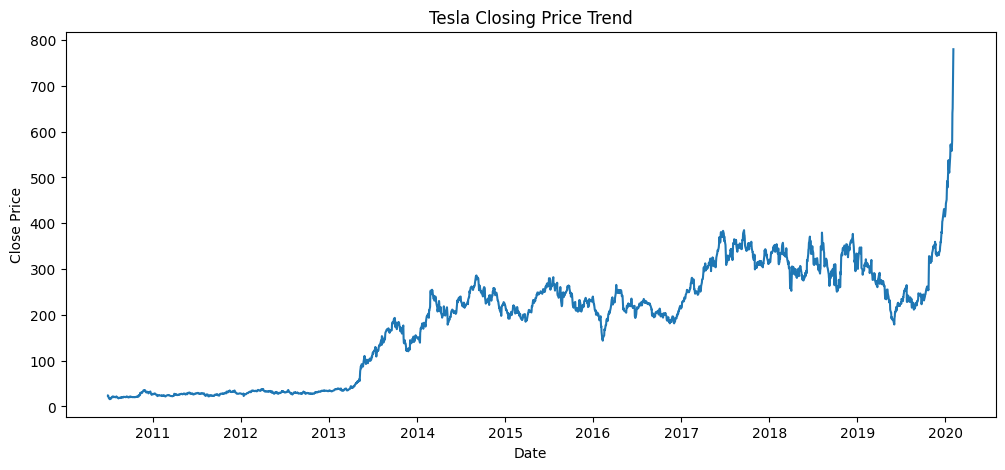

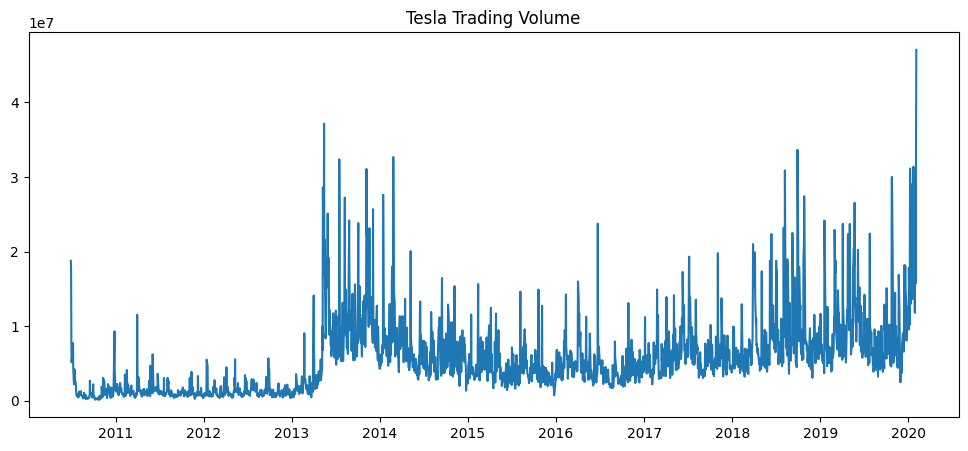

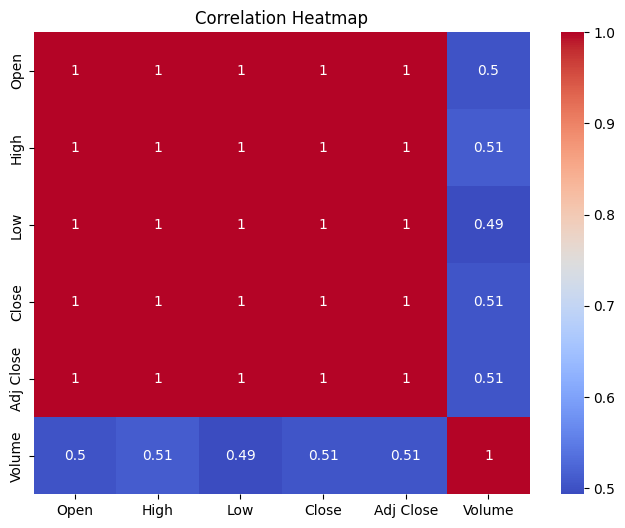


X Shape: (2356, 60, 1)
Y Shape: (2356,)

Train Shape: (1884, 60, 1)
Test Shape: (472, 60, 1)

Training SimpleRNN Model...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0411 - val_loss: 0.0039
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0073 - val_loss: 0.0031
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0047 - val_loss: 0.0019
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0034 - val_loss: 0.0019
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0015 - val_loss: 9.2310e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0014 - val_loss: 9.2466e-04
Epoch 12/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0013

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.0034 - val_loss: 0.0017
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - loss: 7.5030e-04 - val_loss: 0.0015
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 7.7468e-04 - val_loss: 0.0016
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 6.2307e-04 - val_loss: 0.0014
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 5.5944e-04 - val_loss: 0.0017
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

Model Comparison
       Model       RMSE        MAE  R2 Score
0  SimpleRNN  19.805608  13.002460  0.925556
1       LSTM  31.162613  22.759084  0.815703


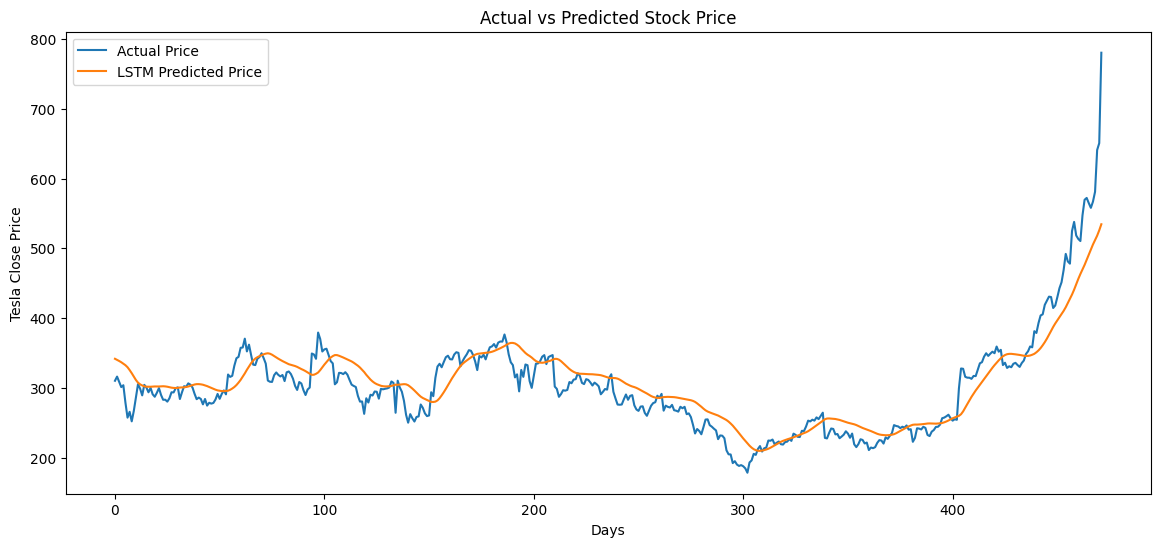

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Predicted Next Day Closing Price:
547.14197



Next 10 Days Forecast:
Day 1: 547.14
Day 2: 555.78
Day 3: 561.38
Day 4: 564.90
Day 5: 566.96
Day 6: 568.00
Day 7: 568.33
Day 8: 568.15
Day 9: 567.62
Day 10: 566.84

Project Completed Successfully!


In [35]:
# ==========================
# TESLA STOCK PRICE PREDICTION
# SIMPLE RNN VS LSTM
# ==========================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("TSLA.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

# ==========================
# DATA PREPROCESSING
# ==========================

print("\nMissing Values:")
print(df.isnull().sum())

# Handle Missing Values
df.fillna(method='ffill', inplace=True)

# Convert Date Column
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# ==========================
# EDA
# ==========================

plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Tesla Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Volume'])
plt.title("Tesla Trading Volume")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ==========================
# FEATURE SELECTION
# ==========================

data = df[['Close']]

# ==========================
# SCALING
# ==========================

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# ==========================
# CREATE SEQUENCES
# ==========================

def create_sequences(dataset, time_step=60):

    X = []
    y = []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 60)

# Reshape for RNN/LSTM

X = X.reshape(X.shape[0], X.shape[1], 1)

print("\nX Shape:", X.shape)
print("Y Shape:", y.shape)

# ==========================
# TRAIN TEST SPLIT
# ==========================

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ==========================
# EARLY STOPPING
# ==========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ==========================
# SIMPLE RNN MODEL
# ==========================

rnn_model = Sequential()

rnn_model.add(
    SimpleRNN(
        units=50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(50))

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

print("\nTraining SimpleRNN Model...")

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    callbacks=[early_stop],
    verbose=1
)

# RNN Prediction

rnn_pred = rnn_model.predict(X_test)

rnn_pred = scaler.inverse_transform(rnn_pred)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

# RNN Evaluation

rnn_rmse = np.sqrt(
    mean_squared_error(actual,rnn_pred)
)

rnn_mae = mean_absolute_error(actual,rnn_pred)

rnn_r2 = r2_score(actual,rnn_pred)

# ==========================
# LSTM MODEL
# ==========================

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(50))

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

print("\nTraining LSTM Model...")

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test),
    callbacks=[early_stop],
    verbose=1
)

# LSTM Prediction

lstm_pred = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

# LSTM Evaluation

lstm_rmse = np.sqrt(
    mean_squared_error(actual,lstm_pred)
)

lstm_mae = mean_absolute_error(actual,lstm_pred)

lstm_r2 = r2_score(actual,lstm_pred)

# ==========================
# RESULTS
# ==========================

results = pd.DataFrame({

    "Model":["SimpleRNN","LSTM"],

    "RMSE":[rnn_rmse,lstm_rmse],

    "MAE":[rnn_mae,lstm_mae],

    "R2 Score":[rnn_r2,lstm_r2]

})

print("\nModel Comparison")
print(results)

# ==========================
# ACTUAL VS PREDICTED
# ==========================

plt.figure(figsize=(14,6))

plt.plot(actual,
         label='Actual Price')

plt.plot(lstm_pred,
         label='LSTM Predicted Price')

plt.title("Actual vs Predicted Stock Price")

plt.xlabel("Days")

plt.ylabel("Tesla Close Price")

plt.legend()

plt.show()

# ==========================
# NEXT DAY PREDICTION
# ==========================

last_60_days = scaled_data[-60:]

X_input = last_60_days.reshape(1,60,1)

next_day = lstm_model.predict(X_input)

next_day = scaler.inverse_transform(next_day)

print("\nPredicted Next Day Closing Price:")
print(next_day[0][0])

# ==========================
# FUTURE 10 DAYS FORECAST
# ==========================

future_input = scaled_data[-60:].flatten().tolist()

future_predictions = []

for i in range(10):

    x = np.array(future_input[-60:])
    x = x.reshape(1,60,1)

    pred = lstm_model.predict(x, verbose=0)

    future_predictions.append(pred[0][0])

    future_input.append(pred[0][0])

future_predictions = np.array(future_predictions).reshape(-1,1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

print("\nNext 10 Days Forecast:")

for i, price in enumerate(future_predictions):

    print(f"Day {i+1}: {price[0]:.2f}")

# ==========================
# SAVE MODEL
# ==========================

lstm_model.save("best_lstm_model.h5")

print("\nProject Completed Successfully!")